# Cow Detection + Behavior Classification Pipeline

End-to-end inference pipeline:

Raw image/video -> YOLO detection -> crop extraction -> ViT behavior classification



In [1]:
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from ultralytics import YOLO




/home/robin/dev/school/research/cow-sam/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration
PREFERRED_YOLO_MODEL_PATH = Path("artifacts/runs/detect/yolo_oneclass/weights/best.pt")
VIT_MODEL_PATH = Path("artifacts/models/cow-behavior-vit")

DETECTION_CONF = 0.25
VIDEO_MAX_FRAMES = 120
ARTIFACTS_DIR = Path("artifacts/pipeline")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

torch.manual_seed(42)




Using CUDA: NVIDIA GeForce RTX 4080


In [3]:
# Load models


def resolve_yolo_model_path(preferred_path: Path) -> Path:
    """Resolve YOLO weights path using preferred path, then latest artifacts fallback."""
    if preferred_path.exists():
        return preferred_path

    candidates = sorted(
        Path("artifacts/runs/detect").rglob("weights/best.pt"),
        key=lambda p: p.stat().st_mtime,
    )
    if candidates:
        latest = candidates[-1]
        print(f"Preferred YOLO path missing. Using latest discovered weights: {latest}")
        return latest

    raise FileNotFoundError(
        "YOLO model not found. Expected either "
        f"{preferred_path} or any artifacts/runs/detect/**/weights/best.pt"
    )


YOLO_MODEL_PATH = resolve_yolo_model_path(PREFERRED_YOLO_MODEL_PATH)

if not VIT_MODEL_PATH.exists():
    raise FileNotFoundError(f"ViT model not found: {VIT_MODEL_PATH}")

detector = YOLO(str(YOLO_MODEL_PATH))
processor = AutoImageProcessor.from_pretrained(str(VIT_MODEL_PATH), use_fast=True)
classifier = AutoModelForImageClassification.from_pretrained(str(VIT_MODEL_PATH)).to(
    device
)
classifier.eval()

id2label = classifier.config.id2label
print(f"Loaded classifier labels: {list(id2label.values())}")




Loading weights: 100%|██████████| 200/200 [00:00<00:00, 531.84it/s, Materializing param=vit.layernorm.weight]                                 


Loaded classifier labels: ['drinking water', 'foraging', 'lying down', 'rumination', 'stand']


In [4]:
def detect_cows(image_bgr, confidence: float = DETECTION_CONF) -> list[list[int]]:
    """Return list of xyxy int boxes for detected cows."""
    result = detector.predict(source=image_bgr, conf=confidence, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        return []
    return result.boxes.xyxy.cpu().numpy().astype(int).tolist()


def classify_behavior(crop_bgr) -> dict[str, float | str]:
    """Classify cow behavior on a cropped BGR image."""
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    inputs = processor(Image.fromarray(crop_rgb), return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = classifier(**inputs).logits
        probs = F.softmax(logits, dim=-1)

    pred_id = int(logits.argmax(-1).item())
    confidence = float(probs[0, pred_id].item())
    return {"class": id2label[pred_id], "conf": confidence}


def annotate_frame(frame_bgr, detections: list[dict]) -> None:
    for item in detections:
        x1, y1, x2, y2 = item["bbox"]
        label = f"{item['behavior']} ({item['conf']:.2f})"
        cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            frame_bgr,
            label,
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
        )


def process_image(image_path: Path) -> tuple[list[dict], Any]:
    """Run detect + classify on a single image and return detections + annotated image."""
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    detections: list[dict] = []
    boxes = detect_cows(image)
    for box in boxes:
        x1, y1, x2, y2 = box
        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        behavior = classify_behavior(crop)
        detections.append(
            {
                "bbox": box,
                "behavior": behavior["class"],
                "conf": behavior["conf"],
            }
        )

    annotated = image.copy()
    annotate_frame(annotated, detections)
    return detections, annotated


def process_video(
    video_path: Path,
    output_path: Path,
    max_frames: int = VIDEO_MAX_FRAMES,
) -> dict[str, float]:
    """Run frame-wise detect + classify and write annotated mp4."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    frame_count = 0
    total_detections = 0
    try:
        while cap.isOpened() and frame_count < max_frames:
            ok, frame = cap.read()
            if not ok:
                break

            boxes = detect_cows(frame)
            frame_detections: list[dict] = []
            for box in boxes:
                x1, y1, x2, y2 = box
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                behavior = classify_behavior(crop)
                frame_detections.append(
                    {
                        "bbox": box,
                        "behavior": behavior["class"],
                        "conf": behavior["conf"],
                    }
                )

            annotate_frame(frame, frame_detections)
            writer.write(frame)

            total_detections += len(frame_detections)
            frame_count += 1
    finally:
        cap.release()
        writer.release()

    return {
        "frames": frame_count,
        "detections": total_detections,
        "fps": fps,
    }




In [5]:
def save_annotated_image_preview(image_path: Path, output_path: Path) -> None:
    detections, annotated = process_image(image_path)
    cv2.imwrite(str(output_path), annotated)

    print(f"{image_path.name}: detected {len(detections)} cows")
    for i, item in enumerate(detections, start=1):
        print(f"  {i}. {item['behavior']} ({item['conf']:.3f})")

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Annotated detections: {image_path.name}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()




## Optional Demo Runs



249_00002.jpg: detected 15 cows
  1. foraging (0.999)
  2. foraging (0.999)
  3. foraging (0.999)
  4. drinking water (0.915)
  5. foraging (0.999)
  6. foraging (0.998)
  7. foraging (0.999)
  8. foraging (0.999)
  9. foraging (0.998)
  10. foraging (0.998)
  11. foraging (0.998)
  12. foraging (0.998)
  13. foraging (0.998)
  14. foraging (0.999)
  15. rumination (0.998)


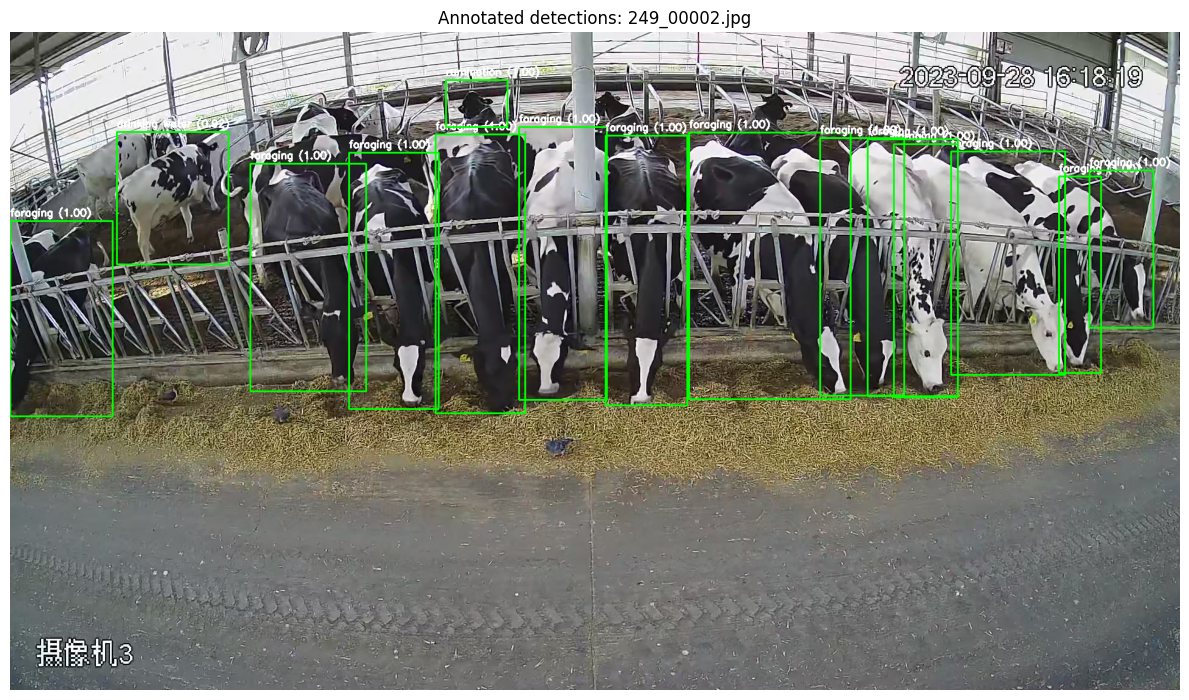

In [6]:
# Image demo
val_dir = Path("workdir/yolo_cow_oneclass/images/val")
if val_dir.exists():
    val_images = list(val_dir.glob("*.jpg"))
    if val_images:
        demo_image = val_images[0]
        save_annotated_image_preview(
            image_path=demo_image,
            output_path=ARTIFACTS_DIR / f"annotated_{demo_image.stem}.jpg",
        )




In [7]:
# Video demo (bounded)
videos_dir = Path("data/videos/videos")
if videos_dir.exists():
    video_files = list(videos_dir.glob("*.mp4"))
    if video_files:
        demo_video = video_files[0]
        output_video = ARTIFACTS_DIR / f"annotated_{demo_video.stem}.mp4"
        stats = process_video(demo_video, output_video, max_frames=VIDEO_MAX_FRAMES)
        print(
            f"Video demo complete -> frames: {stats['frames']}, "
            f"detections: {stats['detections']}, fps: {stats['fps']:.1f}"
        )
        print(f"Saved video: {output_video}")


Video demo complete -> frames: 120, detections: 0, fps: 25.0
Saved video: artifacts/pipeline/annotated_165.mp4
